# Scattered-wave-function (SWF) approach for pair production by curved spacetimes and electromagnetic fields

This code computes the probability of pair production by an arbitrary metric
$g_{\mu\nu}(t,x)$ or electromagnetic gauge potential $A_\mu(t,x)$.

The only assumptions are that

$$
g_{\mu\nu}\to\eta_{\mu\nu}
\qquad
A_\mu\to0 \;,
$$

as $t\to\pm\infty$ and/or $x\to\pm\infty$.

The implementation uses JAX and is designed to run efficiently on GPUs.
The computations presented below were performed on an NVIDIA A100 GPU
using Google Colab.

The implementation is based on the methods developed in:

1. Greger Torgrimsson,\
**Momentum correlation in pair production by spacetime-dependent fields from scattered wave functions**\
Phys. Rev. D **112**, 116011 (2025)


2. Greger Torgrimsson,\
**Solving the Dirac equation on a GPU for strong-field processes in multidimensional background fields**\
arXiv:2512.16889 [hep-ph]

3. P. Semren and G. Torgrimsson,\
**Scattered wave functions and worldline instantons for particle production in curved spacetime**\
(to appear)



This notebook was used to produce the SWF results presented in [3], except for the results for metrics with nontrivial holonomy; those results were instead produced with jaxGR.ipynb.

**Author:** Greger Torgrimsson



# Import

diffrax contains the ODE solver for solving the Dirac equation on a GPU.

In [ ]:
# this is needed when running this code on Colab
%%capture output
%pip install -U "jax[cuda12]"

In [ ]:
# this is needed when running this code on Colab
%%capture output
%pip install diffrax

In [ ]:
import jax
import jax.numpy as np
from diffrax import diffeqsolve, ODETerm, Dopri5, Tsit5, PIDController, SaveAt

import matplotlib.pyplot as plt
from scipy.integrate import simpson
from scipy.interpolate import make_interp_spline, RegularGridInterpolator
from tqdm import tqdm

import sympy as sp
from sympy import I
from sympy import BlockMatrix
from jax.scipy.special import erf as jax_erf

my_modules = [
    {"erf": jax_erf},   # custom overrides
    "jax"               # then fall back to JAX backend
]

In [ ]:
precision=64

if precision==32:
    realType=np.float32
    compType=np.complex64

elif precision==64:
    jax.config.update("jax_enable_x64", True)
    realType=np.float64
    compType=np.complex128

In [ ]:
def toMathematica(arr):
  mathematica_str=str(arr.tolist()).replace('[','{').replace(']','}').replace("e","*10^").replace("j","I").replace("(","").replace(")","")
  print(mathematica_str)

In [ ]:
#tol=1e-7
@jax.jit
def chop(x, tol=1e-10):
    return np.where(np.abs(x) < tol, 0.0, x)

In [ ]:
@jax.jit
def simpson_jax(y, dx=1.0):
    n = y.shape[-1]
    if n % 2 == 1:
        # Odd number of samples → pure Simpson's 1/3 rule
        return (dx/3) * (
            y[..., 0]
            + 4 * np.sum(y[..., 1:-1:2], axis=-1)
            + 2 * np.sum(y[..., 2:-2:2], axis=-1)
            + y[..., -1]
        )
    else:
        # Even number of samples → use Simpson's 1/3 on first n-3, 3/8 on last 4
        y_main = y[..., :-3]
        y_tail = y[..., -4:]

        main = (dx/3) * (
            y_main[..., 0]
            + 4 * np.sum(y_main[..., 1:-1:2], axis=-1)
            + 2 * np.sum(y_main[..., 2:-2:2], axis=-1)
            + y_main[..., -1]
        )

        tail = (3*dx/8) * (
            y_tail[..., 0]
            + 3 * y_tail[..., 1]
            + 3 * y_tail[..., 2]
            + y_tail[..., 3]
        )

        return main + tail

In [ ]:
from datetime import datetime
import time
from IPython import get_ipython

start_time = time.perf_counter()

In [ ]:
def pre_run_cell(info):
    global start_time
    start_time = time.perf_counter()

def post_run_cell(result):
    end_time = time.perf_counter()
    elapsed = end_time - start_time
    print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')} | elapsed time: {elapsed:.3f} s")

ip = get_ipython()
ip.events.register('pre_run_cell', pre_run_cell)
ip.events.register('post_run_cell', post_run_cell)

2026-06-22 07:24:36 | elapsed time: 0.005 s


# Spin define

In [ ]:
g0=sp.Matrix([[0,-I,0,0],[I,0,0,0],[0,0,0,-I],[0,0,I,0]])
g1=sp.Matrix([[0,I,0,0],[I,0,0,0],[0,0,0,I],[0,0,I,0]])
g2=sp.Matrix([[-I,0,0,0],[0,I,0,0],[0,0,I,0],[0,0,0,-I]])
g3=sp.Matrix([[0,0,-I,0],[0,0,0,I],[-I,0,0,0],[0,I,0,0]])

g=[g0,g1,g2,g3]
id=sp.Matrix([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]])
eta=sp.Matrix([[1,0,0,0],[0,-1,0,0],[0,0,-1,0],[0,0,0,-1]])

g5=I*g0*g1*g2*g3

2026-06-22 07:24:42 | elapsed time: 0.006 s


In [ ]:
R1=sp.Matrix([1,0,0,0])
R2=sp.Matrix([0,0,1,0])

P_1, P_2, P_3 = sp.symbols('P_1 P_2 P_3',real=True)
P_0 = sp.sqrt(1+P_1**2+P_2**2+P_3**2)

u_1=(id+P_0*g0+P_1*g1+P_2*g2+P_3*g3)*R1/sp.sqrt(2*P_0*(P_0+P_1))
v_1=(id-P_0*g0-P_1*g1-P_2*g2-P_3*g3)*R1/sp.sqrt(2*P_0*(P_0+P_1))

u_2=(id+P_0*g0+P_1*g1+P_2*g2+P_3*g3)*R2/sp.sqrt(2*P_0*(P_0+P_1))
v_2=(id-P_0*g0-P_1*g1-P_2*g2-P_3*g3)*R2/sp.sqrt(2*P_0*(P_0+P_1))

2026-06-22 07:24:42 | elapsed time: 0.169 s


2026-06-22 07:24:42 | elapsed time: 0.174 s


# Tetrad general

$0=-i\gamma^0(i\gamma^\mu D_\mu-1)\psi=[(\gamma^0)^2(\partial_0+iA_0)+\gamma^0\gamma^k(\partial_k+iA_k)+\gamma^0(-i/4)\gamma^a\omega_{abc}\sigma^{bc}+i\gamma^0]\psi$

$(\gamma^0)^2=g^{00}$

$[\partial_0+iA_0+\alpha^k(\partial_k+iA_k)+W]\psi=0$

where

$\alpha^k=\frac{1}{g^{00}}\gamma^0\gamma^k$

$W=\frac{1}{4g^{00}}\gamma^0\omega_{abc}\gamma^a\gamma^b\gamma^c+\frac{i}{g^{00}}\gamma^0$

Assume that ${e^a}_\mu$ is only nontrivial for $a=\hat{0},\hat{1}$ and $\mu=0,1$

In [ ]:
t,x,y,z = sp.symbols('t x y z', real=True)

e00 = sp.Function('e_00')(t,x)
e01 = sp.Function('e_01')(t,x)
e10 = sp.Function('e_10')(t,x)
e11 = sp.Function('e_11')(t,x)

eud=sp.Matrix([[e00,e01,0,0],[e10,e11,0,0],[0,0,1,0],[0,0,0,1]])

gdd = eud.T * eta * eud

guu = gdd.inv()

edd = eta * eud
edu = sp.simplify(edd * guu)

xu = sp.Matrix([t,x,y,z])

gddd = sp.simplify(sp.Array( [[[sp.diff(gdd[i, j], xu[k])
                               for k in range(4)] for j in range(4)] for i in range(4)] ))

Γudd = sp.simplify(
    sp.Rational(1,2) * sp.tensorcontraction( sp.tensorproduct( guu,
            gddd + sp.permutedims(gddd, (0, 2, 1)) - sp.permutedims(gddd, (2, 1, 0))
        ), (1,2) ) )

ωddd1 = sp.simplify(sp.Array( [[[
            sum(
                edd[a, λ] * sp.diff(edu[b, λ], xu[μ])
                for λ in range(4)
            )
            for b in range(4)] for a in range(4)] for μ in range(4)] ))

ωddd2 = sp.simplify(sp.Array( [[[
            sum(
                edd[a, λ] * Γudd[λ,μ,ν] * edu[b,ν]
                for λ in range(4)  for ν in range(4)
            )
            for b in range(4)] for a in range(4)] for μ in range(4)] ))

ωddd = sp.simplify( sp.tensorcontraction( sp.tensorproduct(edu , (ωddd1 + ωddd2) ) ,(1,2) ) )

2026-06-22 09:27:22 | elapsed time: 3.757 s


In [ ]:
gDim = 2

G = [ sum( ( g[a] * edu[a, mu] for a in range(4) ), sp.zeros(4) ) for mu in range(4) ]

G0, G1, G2, G3 = G

W = sp.simplify(
    sum(
        (  (-I/4) * I * ωddd[a, b, c] * (G0 * g[a] * g[b] * g[c])
        for a in range(4)  for b in range(4)  for c in range(4)  )
        , sp.zeros(4)
    ))

W = sp.simplify((W + I * G0) / guu[0,0])
α1 = sp.simplify(G0 * G1 / guu[0,0])
α2 = sp.simplify(G0 * G2 / guu[0,0])
α3 = sp.simplify(G0 * G3 / guu[0,0])

if gDim==2:
    W  = W[:2, :2]
    α1 = α1[:2, :2]

    u_1 = u_1[:2,0]
    u_2 = u_2[:2,0]
    v_1 = v_1[:2,0]
    v_2 = v_2[:2,0]

2026-06-22 09:27:23 | elapsed time: 0.872 s


2026-06-22 09:27:23 | elapsed time: 0.875 s


2026-06-22 09:27:23 | elapsed time: 0.879 s


# Field define

eud $={e^a}_\mu$

Local lorentz transformation: $\qquad {{e_{\rm new }}^a}_\mu(x)={\Lambda^a}_b(x){{e_{\rm old }}^b}_\mu(x)$

Coordinate transformation: $\qquad x_{\rm old}^\mu=f^\mu(x_{\rm new}) \qquad {{e_{\rm new}}^a}_\mu(x_{\rm new})={{e_{\rm old}}^a}_\nu(f[x_{\rm new}]){f^\nu}_{,\mu}$

In [ ]:
eud

Matrix([
[e_00(t, x), e_01(t, x), 0, 0],
[e_10(t, x), e_11(t, x), 0, 0],
[         0,          0, 1, 0],
[         0,          0, 0, 1]])

2026-06-09 13:28:11 | elapsed time: 0.003 s


Run code in "Tetrad general" again before changing the background, and then the code in "Tetrad specific, grid and project define" afterwards.

In [ ]:
# Example 1:

xDim = 1

ω = sp.Rational(3,10)
κ = ω
v = sp.exp(-(ω*t)**2-(κ*x)**2)

eud_expr = sp.diag(1, sp.exp(v), 1, 1)

# check local Lorentz invariance
# ψ=sp.exp(-(ω*t)**2-(κ*x)**2)
# Λ=sp.Matrix([[sp.cosh(ψ),sp.sinh(ψ),0,0],[sp.sinh(ψ),sp.cosh(ψ),0,0],[0,0,1,0],[0,0,0,1]])
# eud_expr=Λ*eud_expr

# check general covariance
# f0 = t + sp.Rational(1,2)*sp.exp(-(ω*t)**2-(κ*x)**2)
# f1 = x + sp.Rational(1,3)*sp.exp(-(ω*t)**2-(κ*x)**2)
# df = sp.Matrix([[sp.diff(f0,t),sp.diff(f0,x),0,0],[sp.diff(f1,t),sp.diff(f1,x),0,0],[0,0,1,0],[0,0,0,1]])
# eud_expr = sp.simplify(eud_expr.xreplace({t: f0, x: f1})*df)

eud_subs = {e00: eud_expr[0,0], e01: eud_expr[0,1], e10: eud_expr[1,0], e11: eud_expr[1,1]}

ω = float(ω)
κ = float(κ)

def A0(t,x,y,z):
  return 0

def A1(t,x,y,z):
  return 0


xb=15/κ
tin=-3.3/ω; tout=3.3/ω
dx0=.03/κ; dk0=.03; kMax0=30

dx0=np.min(np.array([dx0,np.pi/kMax0]))
nx=np.ceil(1+2*xb/dx0).astype(int)
nk=np.ceil(2*np.pi/(dk0*dx0)).astype(int)

nPad=np.maximum((nk-nx+1)//2,0)
nk=nx+2*nPad

2026-06-22 09:27:25 | elapsed time: 0.010 s


In [ ]:
[v.subs({t: tin, x: 0}),v.subs({t: tout, x: 0})]

[1.86437423315169e-5, 1.86437423315169e-5]

2026-06-22 09:27:27 | elapsed time: 0.004 s


In [ ]:
[nx,nk]

[Array(1001, dtype=int64), Array(2095, dtype=int64)]

2026-06-22 09:27:28 | elapsed time: 0.003 s


In [ ]:
κ*dx0

Array(0.03, dtype=float64)

2026-06-22 09:27:29 | elapsed time: 0.003 s


In [ ]:
# Example 2:

xDim = 1

ω = sp.Rational(3,10)
κ = ω
v = -2*sp.exp(-(ω*t)**2-(κ*x)**2)

eud_expr = sp.diag(1, sp.exp(v), 1, 1)

eud_subs = {e00: eud_expr[0,0], e01: eud_expr[0,1], e10: eud_expr[1,0], e11: eud_expr[1,1]}

ω = float(ω)
κ = float(κ)

def A0(t,x,y,z):
  return 0

def A1(t,x,y,z):
  return 0

xb=15/κ
tin=-3.3/ω; tout=3.3/ω
dx0=.03/κ; dk0=.03; kMax0=30

dx0=np.min(np.array([dx0,np.pi/kMax0]))
nx=np.ceil(1+2*xb/dx0).astype(int)
nk=np.ceil(2*np.pi/(dk0*dx0)).astype(int)

nPad=np.maximum((nk-nx+1)//2,0)
nk=nx+2*nPad

2026-06-22 09:12:05 | elapsed time: 0.009 s


In [ ]:
# Example 3:

xDim = 1

ω = sp.Rational(2,10)
κ = ω
ramp_up=1/(4+sp.exp(4*(ω*t+1)))
ramp_down=1/(1+sp.exp(-4*(ω*t-1)))
v = -sp.exp(-(ramp_up+ramp_down)*(ω*t)**2-(κ*x)**2)

eud_expr = sp.diag(1, sp.exp(v), 1, 1)

eud_subs = {e00: eud_expr[0,0], e01: eud_expr[0,1], e10: eud_expr[1,0], e11: eud_expr[1,1]}


ω = float(ω)
κ = float(κ)

def A0(t,x,y,z):
  return 0

def A1(t,x,y,z):
  return 0

xb=15/κ
tin=-6.7/ω; tout=3.3/ω
dx0=.03/κ; dk0=.03; kMax0=30

dx0=np.min(np.array([dx0,np.pi/kMax0]))
nx=np.ceil(1+2*xb/dx0).astype(int)
nk=np.ceil(2*np.pi/(dk0*dx0)).astype(int)

nPad=np.maximum((nk-nx+1)//2,0)
nk=nx+2*nPad

2026-06-22 09:23:37 | elapsed time: 0.007 s


In [ ]:
[v.subs({t: tin, x: 0}),v.subs({t: tout, x: 0})]

[-1.33699621255202e-5, -1.86642587231116e-5]

2026-06-22 09:23:38 | elapsed time: 0.002 s


In [ ]:
[nx,nk]

[Array(1434, dtype=int64), Array(2002, dtype=int64)]

2026-06-22 09:23:39 | elapsed time: 0.003 s


In [ ]:
κ*dx0

Array(0.02094395, dtype=float64)

2026-06-22 09:23:41 | elapsed time: 0.003 s


# Tetrad specific, grid and project define

In [ ]:
W = W.subs(eud_subs).doit()
α1 = α1.subs(eud_subs).doit()
α2 = α2.subs(eud_subs).doit()
α3 = α3.subs(eud_subs).doit()

2026-06-22 09:27:35 | elapsed time: 0.021 s


In [ ]:
Wback = W - W.applyfunc(lambda e: sp.limit(e, t, sp.oo))
α1back = α1 - α1.applyfunc(lambda e: sp.limit(e, t, sp.oo))
α2back = α2 - α2.applyfunc(lambda e: sp.limit(e, t, sp.oo))
α3back = α3 - α3.applyfunc(lambda e: sp.limit(e, t, sp.oo))

2026-06-22 09:27:35 | elapsed time: 0.072 s


In [ ]:
display(BlockMatrix( [W, Wback, α1, α1back] ) )

Matrix([[Matrix([
[-9*t*exp(-9*t**2/100 - 9*x**2/100)/100,                                      1],
[                                    -1, -9*t*exp(-9*t**2/100 - 9*x**2/100)/100]]), Matrix([
[-9*t*exp(-9*t**2/100 - 9*x**2/100)/100,                                      0],
[                                     0, -9*t*exp(-9*t**2/100 - 9*x**2/100)/100]]), Matrix([
[exp(-exp(-9*t**2/100 - 9*x**2/100)),                                    0],
[                                  0, -exp(-exp(-9*t**2/100 - 9*x**2/100))]]), Matrix([
[-1 + exp(-exp(-9*t**2/100 - 9*x**2/100)),                                       0],
[                                       0, 1 - exp(-exp(-9*t**2/100 - 9*x**2/100))]])]])

2026-06-22 09:27:35 | elapsed time: 0.063 s


In [ ]:
W = sp.lambdify((t,x,y,z), W, modules=my_modules)
α1 = sp.lambdify((t,x,y,z), α1, modules=my_modules)
α2 = sp.lambdify((t,x,y,z), α2, modules=my_modules)
α3 = sp.lambdify((t,x,y,z), α3, modules=my_modules)

Wback = sp.lambdify((t,x,y,z), Wback, modules=my_modules)
α1back = sp.lambdify((t,x,y,z), α1back, modules=my_modules)
α2back = sp.lambdify((t,x,y,z), α2back, modules=my_modules)
α3back = sp.lambdify((t,x,y,z), α3back, modules=my_modules)

u1 = sp.lambdify((P_1, P_2, P_3), u_1, modules=my_modules)
u2 = sp.lambdify((P_1, P_2, P_3), u_2, modules=my_modules)
v1 = sp.lambdify((P_1, P_2, P_3), v_1, modules=my_modules)
v2 = sp.lambdify((P_1, P_2, P_3), v_2, modules=my_modules)

2026-06-22 09:27:35 | elapsed time: 0.037 s


2026-06-22 09:27:35 | elapsed time: 0.041 s


2026-06-22 09:27:35 | elapsed time: 0.045 s


2026-06-22 09:27:35 | elapsed time: 0.049 s


In [ ]:
x0=-xb; x1=xb; dx=(x1-x0)/(nx-1)
xGrid=np.linspace(x0,x1,nx)
dk=2*np.pi/(nk*dx); kMax=dk*(nk-1)/2
kGrid=2*np.pi*np.fft.fftfreq(nk,dx)
nH=round((nx-1)/2)

unPad=tuple(slice(nPad or None,-nPad or None) for _ in range(xDim))
pad_width = tuple([(nPad, nPad)] * xDim + [(0, 0)])

if xDim==1:
  X=xGrid; Y=0; Z=0
  K1=kGrid; K2=0; K3=0
elif xDim==2:
  X,Y=np.meshgrid(xGrid,xGrid,indexing='ij',sparse=True)
  Z=0
  K1,K2=np.meshgrid(kGrid,kGrid,indexing='ij',sparse=True)
  K3=0
elif xDim==3:
  X,Y,Z=np.meshgrid(xGrid,xGrid,xGrid,indexing='ij',sparse=True)
  K1,K2,K3=np.meshgrid(kGrid,kGrid,kGrid,indexing='ij',sparse=True)

2026-06-22 09:27:35 | elapsed time: 0.007 s


In [ ]:
yShape=[2]+xDim*[nx]+[gDim]
psi_out=np.zeros(yShape,dtype=realType)

if xDim==1:
    mat_on_scat = jax.jit(jax.vmap(
        lambda t, x, psi: - ( W(t, x, 0, 0)
                              + 1j*A0(t,x,0,0)*np.eye(2)
                              + 1j*A1(t,x,0,0)*α1(t, x, 0, 0)
                             ) @ psi,
        in_axes=(None, 0, 0)
    ))

    α1_on_x_der = jax.jit(jax.vmap(
        lambda t, x, dpsi: - α1(t, x, 0, 0) @ dpsi,
        in_axes=(None, 0, 0)
    ))

    mat_on_back = jax.jit(jax.vmap(
        lambda t, x, k, sign, u: - ( Wback(t, x, 0, 0)
                                    - 1j*sign*k*α1back(t, x, 0, 0)
                                    + 1j*A0(t,x,0,0)*np.eye(2)
                                    + 1j*A1(t,x,0,0)*α1(t, x, 0, 0)
                                   ) @ u[:,0] * np.exp(-1j*sign*(np.sqrt(1+k**2) * t + k*x)),
        in_axes=(None, 0, None, None, None)
    ))



def makeDer2D(k,sign):

  if sign==1:
    uOut=u1(k,0,0)
  elif sign==-1:
    uOut=v1(k,0,0)

  @jax.jit
  def dPsi(t,y,args):

    psi_scat = y[0] + 1j*y[1]

    der = np.pad(psi_scat, pad_width)
    der = np.fft.fftn(der, axes=tuple(range(xDim)))
    xder = np.fft.ifftn(1j*K1[..., None]*der, axes=tuple(range(xDim)))[unPad]

    dy = mat_on_scat(t,X,psi_scat) + α1_on_x_der(t,X,xder) + mat_on_back(t,X,k,sign,uOut)

    return np.stack([np.real(dy), np.imag(dy)], axis=0)

  return dPsi

2026-06-22 09:27:35 | elapsed time: 0.004 s


In [ ]:
# psi_out_Maj=np.zeros(xDim*[nx]+[gDim],dtype=realType)

# def makeDerMaj2D(k,sign):

#   if sign==1:
#     uOut=u1(k,0,0)
#   elif sign==-1:
#     uOut=v1(k,0,0)

#   @jax.jit
#   def dPsi(t,y,args):

#     der = np.pad(y, pad_width)
#     der = np.fft.fftn(der, axes=tuple(range(xDim)))
#     xder = np.fft.ifftn(1j*K1[..., None]*der, axes=tuple(range(xDim)))[unPad]

#     dy = mat_on_scat(t,X,y) + α1_on_x_der(t,X,xder) + mat_on_back(t,X,k,sign,uOut)

#     return np.real(dy)

#   return dPsi

2026-06-22 09:27:35 | elapsed time: 0.000 s


$u_r^\dagger({\bf q})$ and $v_r^\dagger(-{\bf q})$ for projecting with $(U_{\rm in}[r,{\bf q}]|$ and $(V_{\rm in}[r,-{\bf q}]|$. $r=1,2$ is a spin index, which is irrelevant for the 2D spinors.

Project $\psi_\text{scat.}=\Delta U$ and $\psi_\text{scat.}=\Delta V$ onto in states: $(U_{\rm in}|\Delta U)$, $(V_{\rm in}|\Delta U)$, $(U_{\rm in}|\Delta V)$ and $(V_{\rm in}|\Delta V)$. We can compute these using FFT. First, $f({\bf q}):=(U_{\rm in}[{\bf q}]|\Delta U)=U_{\rm in}^\dagger(r,{\bf q},t_{\rm in},{\bf x}\to 0)\Delta U({\bf q})$. Then, for the next step in the calculation of $N_1$, we express $f({\bf q})=:\int d^3{\bf x}\;e^{i{\bf q}\cdot{\bf x}}f({\bf x})$. U1U etc. below corresponds to $f({\bf x})$.

Solve the Dirac equation, project onto in states, and then perform the integrals in

$$
N_{1\text{vers1}}=\big|{}_m(U_\infty|\Delta V)_n+{}_m(\Delta U|U_\infty)(U_\infty|\Delta V)_n\big|_{t=t_{\rm in}}^2
$$
$$
N_{1\text{vers2}}=\big|{}_m(\Delta U|V_\infty)_n+{}_m(\Delta U|V_\infty)(V_\infty|\Delta V)_n\big|_{t=t_{\rm in}}^2
$$

We compute the integrals over ${\bf q}$ using
$$
\int\frac{d^3{\bf q}}{(2\pi)^3}f^\dagger({\bf q})g({\bf q})=\int d^3{\bf x}f^\dagger({\bf x})g({\bf x})
$$
where $f$ and $g$ are the functions calculated with projectU() and projectV().
We should find $N_{1\text{vers1}}=N_{1\text{vers2}}$ to within the numerical precision.

In [ ]:
pre1D=2/((2*np.pi)**4)
pre2D=2/((2*np.pi)**5)
pre3D=2/((2*np.pi)**6)

2026-06-22 09:27:35 | elapsed time: 0.000 s


In [ ]:
uFFT1 = jax.vmap(lambda k: u1(k, 0, 0)[:,0]*np.exp(-1j*np.sqrt(1+k**2)*tin))(K1)
vFFT1 = jax.vmap(lambda k: v1(-k, 0, 0)[:,0]*np.exp(1j*np.sqrt(1+k**2)*tin))(K1)

uFFT1 = np.conjugate(uFFT1)
vFFT1 = np.conjugate(vFFT1)

2026-06-22 09:27:35 | elapsed time: 0.043 s


In [ ]:
solver = Dopri5()
controller = PIDController(rtol=1e-5, atol=1e-10)
max_steps = 50000

@jax.jit
def doAll2D(p1,q1):
  # global Usol, Vsol, N1vers1, N1vers2, terms1, terms2

  term = ODETerm(makeDer2D(p1,1))
  Uscat = diffeqsolve(term,solver,t0=tout,t1=tin,dt0=-1e-1,y0=psi_out,stepsize_controller=controller,max_steps=max_steps).ys[0]
  Uscat = Uscat[0] + 1j*Uscat[1]

  term = ODETerm(makeDer2D(q1,-1))
  Vscat = diffeqsolve(term,solver,t0=tout,t1=tin,dt0=-1e-1,y0=psi_out,stepsize_controller=controller,max_steps=max_steps).ys[0]
  Vscat = Vscat[0] + 1j*Vscat[1]

  # (U_in|U_scat) and (V_in|U_scat)

  f = np.pad(Uscat, pad_width)
  f = np.fft.ifftn(f, axes=tuple(range(xDim)))
  U1U = np.einsum("ia,ia->i",uFFT1,f)
  U1U=np.fft.fftn(U1U)[unPad]
  V1U = np.einsum("ia,ia->i",vFFT1,f)
  V1U=np.fft.fftn(V1U)[unPad]

  # (U_in|V_scat) and (V_in|V_scat)

  f = np.pad(Vscat, pad_width)
  f = np.fft.ifftn(f, axes=tuple(range(xDim)))
  U1V = np.einsum("ia,ia->i",uFFT1,f)
  U1V=np.fft.fftn(U1V)[unPad]
  V1V = np.einsum("ia,ia->i",vFFT1,f)
  V1V=np.fft.fftn(V1V)[unPad]

  UU1U1V=np.conjugate(U1U)*U1V
  UV1V1V=np.conjugate(V1U)*V1V
  U1Vdelta=np.exp(1j*(p1*X))*U1V
  V1Udelta=np.exp(1j*(q1*X))*np.conjugate(V1U)

  UU1U1V=simpson_jax(UU1U1V,dx)
  U1Vdelta=simpson_jax(U1Vdelta,dx)
  UV1V1V=simpson_jax(UV1V1V,dx)
  V1Udelta=simpson_jax(V1Udelta,dx)

  return np.array([pre1D*np.abs(U1Vdelta+UU1U1V)**2, pre1D*np.abs(V1Udelta+UV1V1V)**2])

2026-06-22 09:27:35 | elapsed time: 0.024 s


2026-06-22 09:27:35 | elapsed time: 0.033 s


# Check code

In [ ]:
P1=1; P2=0; P3=0; delta1=0; delta2=0; delta3=0

p1=-P1+delta1/2; p2=-P2+delta2/2; p3=-P3+delta3/2
q1=P1+delta1/2; q2=P2+delta2/2; q3=P3+delta3/2

2026-06-22 09:28:23 | elapsed time: 0.001 s


In [ ]:
test=doAll2D(p1,q1)

2026-06-22 09:28:28 | elapsed time: 2.973 s


Check that the two formulas for $N_1$ give the same result:

In [ ]:
test[0]/test[1]-1

Array(3.21779475e-07, dtype=float64)

2026-06-22 09:28:29 | elapsed time: 0.004 s


In [ ]:
toMathematica(test[0])

5.593789639906043*10^-08
2026-06-22 09:28:31 | elapsed time: 0.002 s


Plot the scattered wave function to make sure that the x range is sufficiently wide:

In [ ]:
term = ODETerm(makeDer2D(p1,1))
Uscat = diffeqsolve(term,solver,t0=tout,t1=tin,dt0=-1e-2,y0=psi_out,stepsize_controller=controller,max_steps=20000).ys[0]
Uscat = Uscat[0] + 1j*Uscat[1]

2026-06-22 09:28:36 | elapsed time: 1.603 s


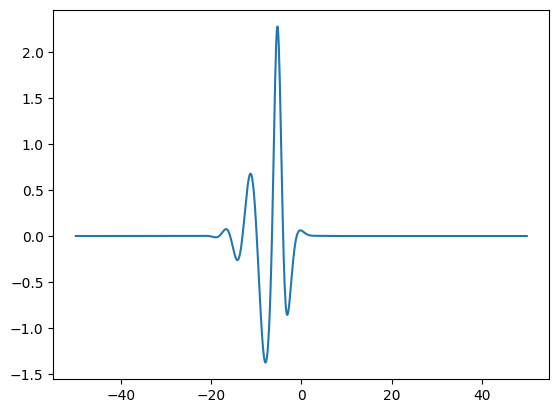

2026-06-22 09:28:36 | elapsed time: 0.121 s


In [ ]:
plt.plot(X,np.imag(Uscat[:,0]))

In [ ]:
term = ODETerm(makeDer2D(q1,-1))
Vscat = diffeqsolve(term,solver,t0=tout,t1=tin,dt0=-1e-1,y0=psi_out,stepsize_controller=controller,max_steps=20000).ys[0]
Vscat = Vscat[0] + 1j*Vscat[1]

2026-06-22 09:28:39 | elapsed time: 1.570 s


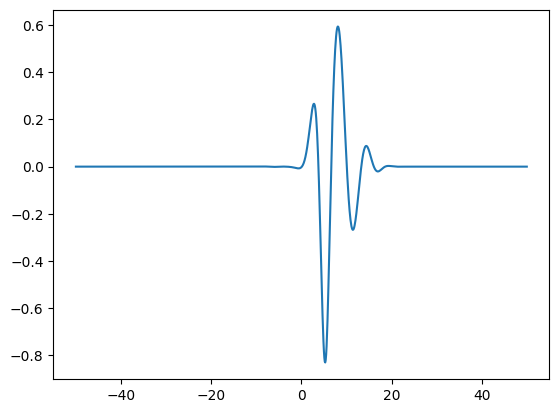

2026-06-22 09:28:39 | elapsed time: 0.113 s


In [ ]:
plt.plot(X,np.imag(Vscat[:,0]))

# Plots

Compute $N_1(p,q)$ on a $100\times100$ grid of $(p,q)$ values in parallel using jax.vmap:

In [ ]:
2+1.5/2

2.75

2026-06-22 09:28:56 | elapsed time: 0.002 s


In [ ]:
pmin=-2.75; pmax=2.75; dp=(pmax-pmin)/100.
pList=np.arange(pmin,pmax+dp,dp)

def inner(p1):
    return jax.vmap(lambda q1: doAll2D(-p1, -q1))(pList)

batched_2D = jax.jit(jax.vmap(inner))

N_values2D = batched_2D(pList)

2026-06-22 09:29:13 | elapsed time: 6.121 s


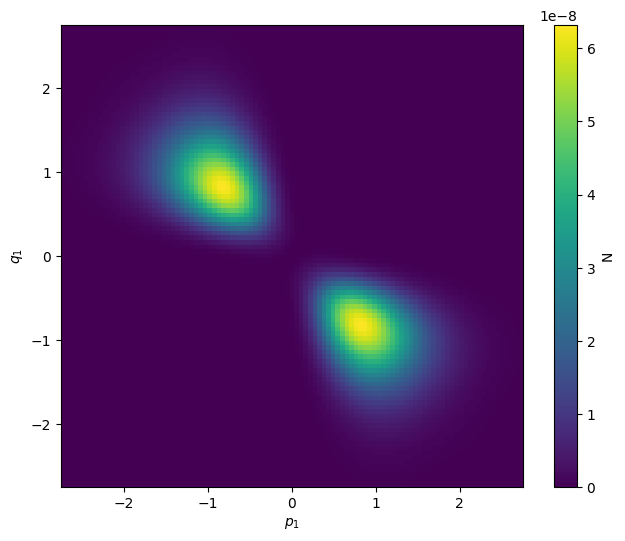

2026-06-22 09:29:13 | elapsed time: 0.169 s


In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(
    N_values2D[:, :, 0].T,
    origin="lower",
    extent=[pList[0], pList[-1], pList[0], pList[-1]]
)
plt.colorbar(label="N")
plt.xlabel(r"$p_1$")
plt.ylabel(r"$q_1$")
plt.show()

In [ ]:
toMathematica(pList)

In [ ]:
toMathematica(N_values2D[:, :, 0])

$P=\frac{q-p}{2}\qquad \Delta=q+p$

In [ ]:
import matplotlib.colors as mcolors

colist = 3*[(0.54, 0.2, 0.14), (1.0, 0.38, 0.01),(1.0, 1.0, 0.6)]
cmap = mcolors.LinearSegmentedColormap.from_list( "myblend", colist)

2026-06-22 09:29:26 | elapsed time: 0.001 s


In [ ]:
from scipy.ndimage import zoom

N_fine = zoom(N_values2D[:, :, 0], 4, order=3)

pList_fine = np.linspace(pList[0], pList[-1], N_fine.shape[0])

P_grid_fine = (pList_fine[None, :] - pList_fine[:, None]) / 2
Delta_grid_fine = pList_fine[:, None] + pList_fine[None, :]

2026-06-22 09:29:27 | elapsed time: 0.022 s


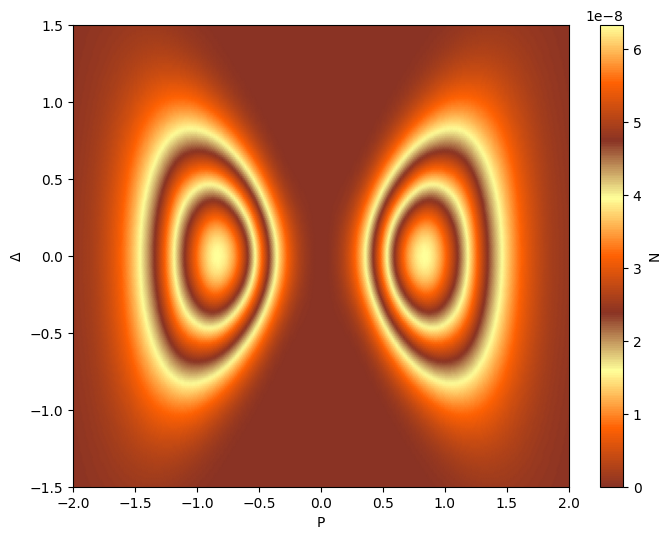

2026-06-22 09:29:44 | elapsed time: 1.102 s


In [ ]:
plt.figure(figsize=(8,6))
plt.pcolormesh(
    P_grid_fine,
    Delta_grid_fine,
    N_fine,
    shading="gouraud",
    cmap=cmap
)
plt.colorbar(label="N")
plt.xlabel("P")
plt.ylabel(r"$\Delta$")
plt.xlim(-2,2)
plt.ylim(-1.5,1.5)
plt.show()

Compute $N_1$ for $-p=q=P$:

In [ ]:
pmin=-2.5; pmax=2.5; dp=(pmax-pmin)/100.
pList=np.arange(pmin,pmax+dp,dp)

batched = jax.jit(jax.vmap(lambda p: doAll2D(p,-p)))
values1 = batched(pList)

2026-06-22 09:30:17 | elapsed time: 4.733 s


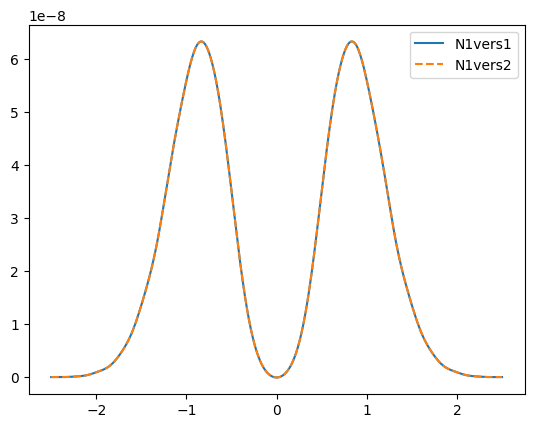

2026-06-22 09:30:17 | elapsed time: 0.115 s


In [ ]:
inter1=make_interp_spline(pList,values1[:,0], k=3)
inter2=make_interp_spline(pList,values1[:,1], k=3)

pDense=np.linspace(pList.min(), pList.max(), 500)
dense1=inter1(pDense)
dense2=inter2(pDense)

plt.plot(pDense,dense1,label='N1vers1')
plt.plot(pDense,dense2,label='N1vers2',linestyle="--")
plt.legend()
plt.show()

In [ ]:
toMathematica(values1[:,0])

{7.758248714052918*10^-11, 8.635299439419106*10^-11, 8.051515878250216*10^-11, 8.309974404323204*10^-11, 1.1260675514876109*10^-10, 1.6316676784524706*10^-10, 2.2255618271846063*10^-10, 3.02944591024417*10^-10, 4.490111048797425*10^-10, 6.873147834473402*10^-10, 9.81457486769213*10^-10, 1.2887399835991778*10^-09, 1.6549986100035223*10^-09, 2.1986736271638695*10^-09, 3.0035198272896987*10^-09, 4.053882967214302*10^-09, 5.298566784956862*10^-09, 6.7774614684912685*10^-09, 8.631588036866732*10^-09, 1.0941310494821303*10^-08, 1.3610538677341944*10^-08, 1.6497001868312628*10^-08, 1.9642066912690226*10^-08, 2.330049240695343*10^-08, 2.7681150813774837*10^-08, 3.2683255692009177*10^-08, 3.789743258581877*10^-08, 4.2896384247055297*10^-08, 4.752953475201889*10^-08, 5.187603101844488*10^-08, 5.593789639906041*10^-08, 5.946196191877409*10^-08, 6.201134643866368*10^-08, 6.3205652908398*10^-08, 6.29214031327367*10^-08, 6.120771123228736*10^-08, 5.818167982045191*10^-08, 5.392660222412331*10^-08, 4

# Check spin

In [ ]:
display(BlockMatrix(g))

In [ ]:
g5

Matrix([
[0,  0, -I, 0],
[0,  0,  0, I],
[I,  0,  0, 0],
[0, -I,  0, 0]])

2026-05-24 10:54:04 | elapsed time: 0.003 s


In [ ]:
display(BlockMatrix([[g[a]*g[b] + g[b]*g[a] - 2*eta[a,b]*id  for b in range(4)] for a in range(4)]))

Matrix([
[Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])],
[Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])],
[Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])],
[Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0,

2026-05-24 10:54:05 | elapsed time: 0.009 s


In [ ]:
g5*g5

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0],
[0, 0, 1, 0],
[0, 0, 0, 1]])

2026-05-24 10:54:06 | elapsed time: 0.002 s


In [ ]:
display(BlockMatrix([g5*g[a] + g[a]*g5  for a in range(4)]))

Matrix([[Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])]])

2026-05-24 10:54:07 | elapsed time: 0.003 s


In [ ]:
display(BlockMatrix([g[a].H-g0*g[a]*g0 for a in range(4)]))

Matrix([[Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])]])

2026-05-24 10:54:08 | elapsed time: 0.004 s


In [ ]:
g5.H-g5

Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])

2026-05-24 10:54:09 | elapsed time: 0.003 s


$u^\dagger_s({\bf p})=v_s({\bf p})$ in Majorana, so $v_s u_r=\delta_{sr}$

In [ ]:
display(BlockMatrix([sp.simplify(v_1.T*u_1),sp.simplify(v_2.T*u_2),sp.simplify(v_1.T*u_2)]))

Matrix([[Matrix([[1]]), Matrix([[1]]), Matrix([[0]])]])

2026-05-24 10:57:51 | elapsed time: 0.042 s


$v^\dagger(-{\bf p})u({\bf p})=0$

In [ ]:
display(BlockMatrix([sp.simplify(u_1.subs({P_1:-P_1,P_2:-P_2,P_3:-P_3}).T*u_1),sp.simplify(u_2.subs({P_1:-P_1,P_2:-P_2,P_3:-P_3}).T*u_1),sp.simplify(u_2.subs({P_1:-P_1,P_2:-P_2,P_3:-P_3}).T*u_2)]))

Matrix([[Matrix([[0]]), Matrix([[0]]), Matrix([[0]])]])

2026-05-24 10:57:57 | elapsed time: 0.047 s


In [ ]:
sp.simplify((-id+P_0*g0+P_1*g1+P_2*g2+P_3*g3)*u_1)

Matrix([
[0],
[0],
[0],
[0]])

2026-05-24 10:58:00 | elapsed time: 0.032 s


In [ ]:
sp.simplify((-id+P_0*g0+P_1*g1+P_2*g2+P_3*g3)*u_2)

Matrix([
[0],
[0],
[0],
[0]])

2026-05-24 10:58:04 | elapsed time: 0.017 s


In [ ]:
sp.simplify((id+P_0*g0+P_1*g1+P_2*g2+P_3*g3)*v_1)

Matrix([
[0],
[0],
[0],
[0]])

2026-05-24 10:58:05 | elapsed time: 0.029 s


In [ ]:
sp.simplify((id+P_0*g0+P_1*g1+P_2*g2+P_3*g3)*v_2)

Matrix([
[0],
[0],
[0],
[0]])

2026-05-24 10:58:05 | elapsed time: 0.026 s


In [ ]:
uSigma=[id,I*g2*g3,I*g3*g1,I*g1*g2]
vSigma=[id,-I*g2*g3,-I*g3*g1,-I*g1*g2]

2026-05-24 10:58:07 | elapsed time: 0.001 s


In [ ]:
display(BlockMatrix([sp.simplify((v_1.T*uSigma[a]*u_1).subs({P_1:0,P_2:0,P_3:0})) for a in range(4)]))

Matrix([[Matrix([[1]]), Matrix([[0]]), Matrix([[0]]), Matrix([[1]])]])

2026-05-24 10:58:07 | elapsed time: 0.008 s


In [ ]:
display(BlockMatrix([sp.simplify((v_2.T*uSigma[a]*u_2).subs({P_1:0,P_2:0,P_3:0})) for a in range(4)]))

Matrix([[Matrix([[1]]), Matrix([[0]]), Matrix([[0]]), Matrix([[-1]])]])

2026-05-24 10:58:08 | elapsed time: 0.005 s


In [ ]:
display(BlockMatrix([sp.simplify((u_1.T*vSigma[a]*v_1).subs({P_1:0,P_2:0,P_3:0})) for a in range(4)]))

Matrix([[Matrix([[1]]), Matrix([[0]]), Matrix([[0]]), Matrix([[1]])]])

2026-05-24 10:58:09 | elapsed time: 0.004 s


In [ ]:
display(BlockMatrix([sp.simplify((u_2.T*vSigma[a]*v_2).subs({P_1:0,P_2:0,P_3:0})) for a in range(4)]))

Matrix([[Matrix([[1]]), Matrix([[0]]), Matrix([[0]]), Matrix([[-1]])]])

2026-05-24 10:58:09 | elapsed time: 0.004 s


# Check field

check ${e^\mu}_a{e^a}_\nu=\delta^\mu_\nu$

In [ ]:
sp.simplify(edu.T*eud)

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0],
[0, 0, 1, 0],
[0, 0, 0, 1]])

2026-06-22 09:32:54 | elapsed time: 0.012 s


check ${e_a}^\mu{e_\mu}^b=\delta_a^b$

In [ ]:
sp.simplify(edu*eud.T)

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0],
[0, 0, 1, 0],
[0, 0, 0, 1]])

2026-06-22 09:33:05 | elapsed time: 0.008 s


In [ ]:
sp.simplify(eud.T*eta*eud-gdd)

Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])

2026-06-22 09:35:29 | elapsed time: 0.003 s


In [ ]:
display(BlockMatrix( [[ sp.simplify(G[a]*G[b] + G[b]*G[a] - 2*guu[a,b]*id)  for b in range(4) ] for a in range(4) ] ))

Matrix([
[Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])],
[Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])],
[Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])],
[Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]]), Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0,

2026-06-22 09:33:09 | elapsed time: 0.575 s


In [ ]:
gdd

Matrix([
[                e_00(t, x)**2 - e_10(t, x)**2, e_00(t, x)*e_01(t, x) - e_10(t, x)*e_11(t, x),  0,  0],
[e_00(t, x)*e_01(t, x) - e_10(t, x)*e_11(t, x),                 e_01(t, x)**2 - e_11(t, x)**2,  0,  0],
[                                            0,                                             0, -1,  0],
[                                            0,                                             0,  0, -1]])

2026-06-22 09:33:23 | elapsed time: 0.006 s


In [ ]:
guu

Matrix([
[               (-e_01(t, x)**2 + e_11(t, x)**2)/(e_00(t, x)**2*e_11(t, x)**2 - 2*e_00(t, x)*e_01(t, x)*e_10(t, x)*e_11(t, x) + e_01(t, x)**2*e_10(t, x)**2), (e_00(t, x)*e_01(t, x) - e_10(t, x)*e_11(t, x))/(e_00(t, x)**2*e_11(t, x)**2 - 2*e_00(t, x)*e_01(t, x)*e_10(t, x)*e_11(t, x) + e_01(t, x)**2*e_10(t, x)**2),  0,  0],
[(e_00(t, x)*e_01(t, x) - e_10(t, x)*e_11(t, x))/(e_00(t, x)**2*e_11(t, x)**2 - 2*e_00(t, x)*e_01(t, x)*e_10(t, x)*e_11(t, x) + e_01(t, x)**2*e_10(t, x)**2),                (-e_00(t, x)**2 + e_10(t, x)**2)/(e_00(t, x)**2*e_11(t, x)**2 - 2*e_00(t, x)*e_01(t, x)*e_10(t, x)*e_11(t, x) + e_01(t, x)**2*e_10(t, x)**2),  0,  0],
[                                                                                                                                                          0,                                                                                                                                                           0, -1,  0],
[                  

2026-06-22 09:33:25 | elapsed time: 0.012 s


In [ ]:
sp.simplify(guu*gdd)

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0],
[0, 0, 1, 0],
[0, 0, 0, 1]])

2026-06-22 09:33:26 | elapsed time: 0.058 s
